(generalized-ellipsoid)=

# 广义椭球函数


`Gal3D` 默认采用嵌套的广义椭球函数来拟合星系的三维形态。本章节将详细介绍广义椭球函数的定义及其拟合方法。

**经典椭球函数**

经典椭球函数为：

$$
\left(\frac{x}{a}\right)^2 + \left(\frac{y}{b}\right)^2 + \left(\frac{z}{c}\right)^2 
$$

该函数描述了一个标准椭球，其形状由参数 $a$、$b$ 和 $c$ 决定，分别表示椭球在 $x$、$y$ 和 $z$ 方向上的半轴长度。


**广义椭球函数**

在``Gal3D``  中，标准椭球函数引入了形状指数，广义椭球函数定义为：

$$
\Bigl[\Bigl(\frac{x}{a}\Bigr)^2\Bigr]^{S_a}
+\Bigl[\Bigl(\frac{y}{b}\Bigr)^2\Bigr]^{S_b}
+\Bigl[\Bigl(\frac{z}{c}\Bigr)^2\Bigr]^{S_c}
$$

当 $S_a=S_b=S_c=1$ 时，广义椭球函数退化为标准椭球函数。形状指数的引入使得椭球的形状更加灵活，可以模拟更复杂的几何结构。

```{seealso}
不同形状参数下的椭球体可视化参见 {ref}`不同形状参数的椭球体 <ellipsoid-shape-show>`。
```


## 如何定义点在曲面上
对于广义椭球函数：

$$
f(x,y,z) \;=\; \Bigl[\Bigl(\frac{x}{a}\Bigr)^2\Bigr]^{S_a}
+\Bigl[\Bigl(\frac{y}{b}\Bigr)^2\Bigr]^{S_b}
+\Bigl[\Bigl(\frac{z}{c}\Bigr)^2\Bigr]^{S_c}
$$

定义当某点 $(x, y, z)$ 满足 $f(x, y, z) = 1$ 时，点在曲面上。

但直接采用 $f(x, y, z)$，其数值会受到形状指数 $S_a, S_b, S_c$ 的影响，且随坐标增大而剧增，导致数值求解不稳定。

因此，重新定义距离比函数 $d(x, y, z)$：

$$
d(x, y, z) = \frac{\sqrt{x^2 + y^2 + z^2}}{\sqrt{x_e^2 + y_e^2 + z_e^2}}
$$

其中 $(x_e, y_e, z_e) = k(x, y, z)$，且 $f(x_e, y_e, z_e) = 1$。  
$d(x, y, z)$ 衡量点到原点的距离与该方向上椭球面点到原点距离之比。当 $d(x, y, z) = 1$ 时，点在曲面上。


以下示例展示了 $f(x, y, z)$ 和 $d(x, y, z)$ 在空间中的分布。可以看到，$d(x, y, z)$ 在不同形状指数下变化更为线性（等值线分布更均匀），而 $f(x, y, z)$ 受指数影响显著。

### 标准椭球体 ($S_a = S_b = 1$) 的空间分布

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from gal3d.visualization.show import show_contour
from gal3d.shape import Geometry

def plot_ellipsoid_s_fvsd(ellipsoid_s, xd=5, yd=5, nx=300, ny=300):
    
    x = np.linspace(-xd, xd, nx)
    y = np.linspace(-yd, yd, ny)
    xx, yy = np.meshgrid(x, y)
    pos = np.stack([xx, yy, np.zeros_like(xx)], axis=-1)

    fig, axes = plt.subplots(1, 2, figsize=(8, 5))

    # f(x,y,z)
    values1 = ellipsoid_s(pos)
    norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=values1.max())
    im1 = axes[0].imshow(values1.reshape(nx, ny), cmap='RdBu', extent=[-xd, xd, -yd, yd], origin='lower', norm=norm1)
    show_contour(values1.reshape(nx, ny), xs=x, ys=y, axesObj=axes[0], logscale=False, levels=np.linspace(0, values1.max(), 20))
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    cb1 = fig.colorbar(im1, ax=axes[0], orientation='horizontal', location="top", pad=0.)
    cb1.set_label('Ellipsoid f(x,y,z)', fontsize=12)

    # d(x,y,z)
    values2 = ellipsoid_s.f_ray_d(pos)
    norm2 = mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=values2.max())
    im2 = axes[1].imshow(values2.reshape(nx, ny), cmap='RdBu', extent=[-xd, xd, -yd, yd], origin='lower', norm=norm2)
    show_contour(values2.reshape(nx, ny), xs=x, ys=y, axesObj=axes[1], logscale=False, levels=np.linspace(0, values2.max(), 20))
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    cb2 = fig.colorbar(im2, ax=axes[1], orientation='horizontal', location="top", pad=0.)
    cb2.set_label('Ellipsoid d(x,y,z)', fontsize=12)

    plt.tight_layout()
    plt.show()
    
def plot_value_along_a(ellipsoid_s,xd=5,nbins=300):
    x = np.linspace(-xd,xd,nbins)
    t = np.array([x,np.zeros(x.size),np.zeros(x.size)]).T
    
    plt.figure(figsize=(4,3))
    plt.plot(x,ellipsoid_s(t),label="f",c='k')
    plt.plot(x,ellipsoid_s.f_ray_d(t),label="d",c='r')
    plt.xlabel("X")
    plt.ylabel("Value")
    plt.legend()

ellipsoid_s = Geometry.get_plugin("Ellipsoid_S")
ellipsoid_s = ellipsoid_s(**ellipsoid_s.default_parameters())
ellipsoid_s.parameters['eps_ab'] = 0.5
ellipsoid_s.parameters

Parameters(
  a       = 3.000  [0.100, inf]
  eps_ab  = 0.500  [0.001, 0.999]
  eps_bc  = 0.500  [0.001, 0.999]
  sa      = 1.000  [0.200, 2.000]
  sb      = 1.000  [0.200, 2.000]
  sc      = 1.000  [0.200, 2.000]
)

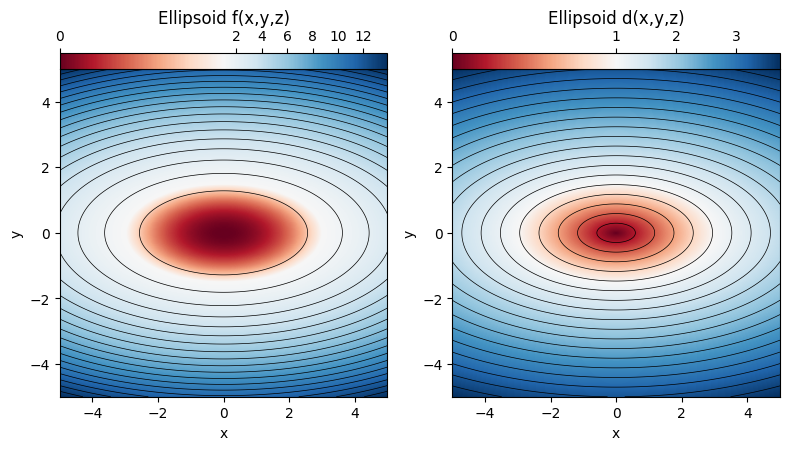

In [2]:
plot_ellipsoid_s_fvsd(ellipsoid_s)

沿主轴方向 $f$和 $d$ 的值的变化，

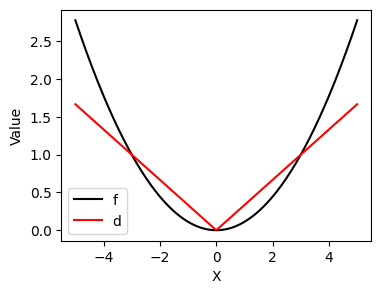

In [3]:
plot_value_along_a(ellipsoid_s)

### 形状指数 $S_a = S_b = 0.2$ 时的空间分布

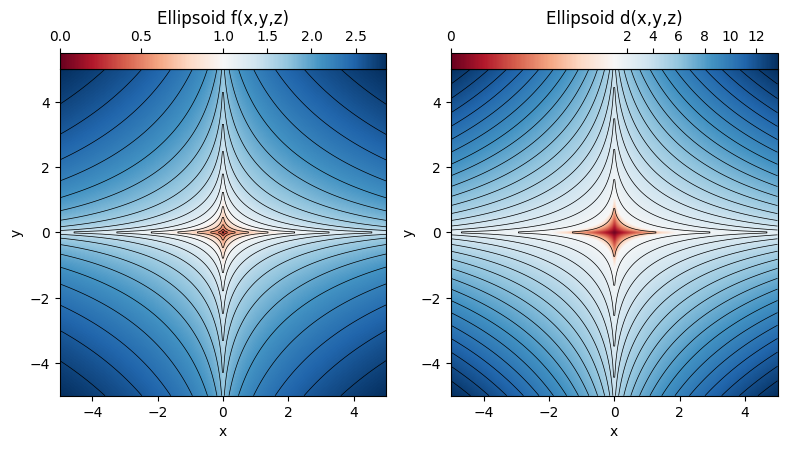

In [4]:
ellipsoid_s.parameters['sa'] = 0.2
ellipsoid_s.parameters['sb'] = 0.2
plot_ellipsoid_s_fvsd(ellipsoid_s)

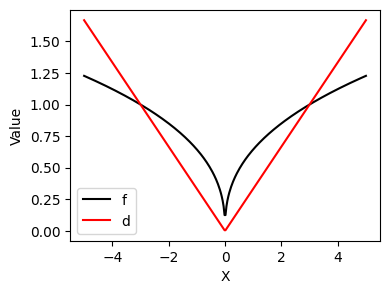

In [5]:
plot_value_along_a(ellipsoid_s)

### 形状指数 $S_a = S_b = 2$ 时的空间分布

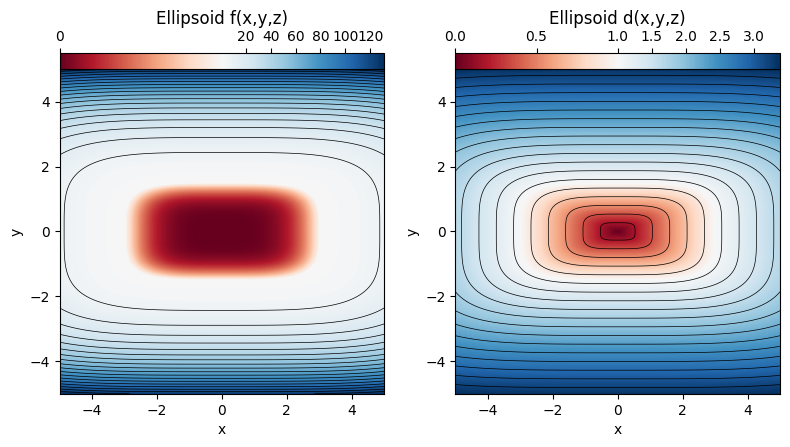

In [6]:
ellipsoid_s.parameters['sa'] = 2
ellipsoid_s.parameters['sb'] = 2
plot_ellipsoid_s_fvsd(ellipsoid_s)

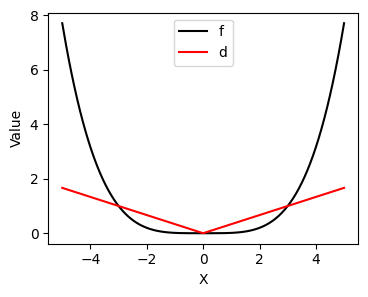

In [7]:
plot_value_along_a(ellipsoid_s)

## 求解任意方向上椭球面上的点


计算 $d(x, y, z)$ 的关键在于，需在 $(x, y, z)$ 方向上找到广义椭球曲面上的点 $(x_e, y_e, z_e)$。
`Gal3d` 提供了多种数值迭代方法，包括 Newton 法、Halley 法和 Householder 法，用于求解该点的坐标。


**问题定义**

对于给定的 $(x, y, z)$、椭球参数 $(a, b, c)$ 及形状指数 $(S_a, S_b, S_c)$，我们需要求解比例因子 $k$，使得：

$$(x_e, y_e, z_e) = k(x, y, z)$$

并满足广义椭球方程：

$$ f(x_e, y_e, z_e) = 1 $$

即：

$$ f(kx, ky, kz) = \left(\frac{kx}{a}\right)^{2S_a} + \left(\frac{ky}{b}\right)^{2S_b} + \left(\frac{kz}{c}\right)^{2S_c} $$

记 $f(k) = f(kx, ky, kz)$。


**数值迭代方法**


```{note}
:class: margin
Newton 法、Halley 法和 Householder 法的收敛速度依次递增，但 Halley 法和 Householder 法单次迭代计算量更大。在实际应用中，三者的差异不大。由于 Newton 法在某些极端情况下可能不收敛，`Gal3d` 默认使用 Halley 法。
对于这里计算方向距离比 `d(x, y, z)` 的过程，主要可修改的是 `config.ellipsoid_s.DistIteration`：

```python
from gal3d.configuration import config, IterationMethod

config.ellipsoid_s.DistIteration = IterationMethod.NEWTON

```

为了数值迭代，定义误差函数：

$$ F(k) = (f(k) - 1)^2 $$

迭代方法的一般形式为：

$$ k_{n+1} = k_n - \Delta $$

其中 $\Delta$ 为步长，不同方法的具体表达如下：

Newton 法：

$$k_{n+1} = k_n - \frac{F(k_n)}{F'(k_n)}$$

Halley 法：

$$k_{n+1} = k_n - \frac{2F(k_n)F'(k_n)}{2F'(k_n)^2 +F''(k_n)F(k_n)}$$

Householder 法：

$$k_{n+1} = k_n - \frac{6FF'^2-3F^2F''}{6F'^3-6FF'F''+F^2F''}$$


**导数计算**

误差函数 $F(k)$ 的一阶、二阶和三阶导数分别为：

$$F'(k) = 2(f(k)-1)f'(k)$$

$$F''(k) =2(f(k)-1)f''(k) + 2f'(k)^2$$

$$F'''(k) = 2(f(k)-1)f'''(k) + 6f'(k)f''(k)$$

其中 $f(k)$ 的一阶、二阶和三阶导数分别为：

$$f'(k) = \frac{2S_a}{k}(\frac{xk}{a})^{2_a} + \frac{2S_b}{k}(\frac{yk}{b})^{2S_b} + \frac{2S_c}{k}(\frac{zk}{c})^{2S_c}$$

$$f''(k) = \frac{2S_a(2S_a-1)}{k^2}(\frac{xk}{a})^{2_a} + \frac{2S_b(2S_b-1)}{k^2}(\frac{yk}{b})^{2S_b} + \frac{2S_c(2S_c-1)}{k^2}(\frac{zk}{c})^{2S_c}$$

$$f'''(k) = \frac{2S_a(2S_a-1)(2S_a-2)}{k^3}(\frac{xk}{a})^{2_a} + \frac{2S_b(2S_b-1)(2S_b-2)}{k^3}(\frac{yk}{b})^{2S_b} + \frac{2S_c(2S_c-1)(2S_c-2)}{k^3}(\frac{zk}{c})^{2S_c}$$


**自适应步长策略**

此外，`Gal3d`实现了自适应步长策略：每次迭代时，步长乘以自适应因子 $\lambda$，即：

$$k_{n+1} = k_n - \lambda \Delta$$

并动态调整 $\lambda$，以确保 $F(k_{n+1}) < F(k_n)$，从而提高收敛效率与稳定性。


```{note}
在实际拟合中，通过球面均匀采样 n 个点，然后最小化误差函数

$$\chi^2 = \sum_{i=1}^{n} r_i^2(d(x_i, y_i, z_i)-1)^2$$

该误差函数中系数 $r_i^2$ 代表了每个采样点的近似面积权重